# Comparison openmp compilation

After some artifacts in the radiationfields were noticed, this notebook compares two ICON model runs that were done with exactly the same setup — the only difference is that one was compiled with OpenMP (`--enable-openmp`) and the other without. 




In [1]:
%matplotlib inline

# system libs
import os, sys, glob
import datetime

# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# plotting
import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

import warnings
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import matplotlib.tri as tri

## Open datasets and format time

In [2]:
# Konfiguration: Cases mit zugehörigen Runs
cases = {
    "20240806": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar1-20240806-exp008",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar1-20240806-exp008"
    },
    "20240928": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar2-20240928-exp001",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp001"
    },
    "20241110": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar3-20241110-exp001",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar3-20241110-exp001"
    }
}

In [3]:
'''
Bsp.Zugriff auf Daten:
2D-Daten: data2d["20240806"]["openmp"]["d3"]
3D-Daten: data3d["20240806"]["noopenmp"]["d1"]
Grid: grids["20240806"]["openmp"]["d3"]
'''

data2d = {}
data3d = {}
grids = {}

for date, runs in cases.items():
    data2d[date] = {}
    data3d[date] = {}
    grids[date] = {}
    for run_name, path in runs.items():
        # 2D- und 3D-Daten laden
        data2d[date][run_name] = {
            f"d{dom}": xr.open_mfdataset(f"{path}/2d_*_DOM0{dom}_ML_{date}T????00Z.nc")
            for dom in range(1, 4)
        }
        data3d[date][run_name] = {
            f"d{dom}": xr.open_mfdataset(f"{path}/3d_*_DOM0{dom}_?L_{date}T????00Z.nc")
            for dom in range(1, 4)
        }

        # Grid-Dateien laden
        grids[date][run_name] = {
            f"d{dom}": xr.open_dataset(f"{path}/domain{dom}_DOM0{dom}.nc")
            for dom in range(1, 4)
        }

In [4]:
#convert time
for date in data2d:
    for run in data2d[date]:
        for dom in data2d[date][run]:
            data2d[date][run][dom]['time'] = convert_timevec(data2d[date][run][dom].time.data)
            data3d[date][run][dom]['time'] = convert_timevec(data3d[date][run][dom].time.data)

## tripcolor-Maps comparison

In [5]:
def plot_case_comparison_map(data2d, grids, case_date, dom="3", var="sod_t", time_str="15:00:00", run1="openmp", run2="noopenmp"):
    """
    Vergleicht zwei ICON-Runs in einem bestimmten Fall (Datum) anhand einer Variable zu einem Zeitpunkt.
    Zeigt drei Subplots: run1, run2, Differenz.
    
    Parameters:
    - data2d: dict[date][run][dom] → xarray.Dataset mit 2D-Daten
    - grids:  dict[date][run][dom] → xarray.Dataset mit Grid-Informationen
    - case_date: str, z. B. "20240928"
    - dom: str, Domain (z. B. "1", "2", "3")
    - var: str, Name der zu vergleichenden Variable (z. B. "sod_t")
    - time_str: str, Zeit in ISO-Format (z. B. "15:00:00")
    - run1/run2: str, Namen der zu vergleichenden Runs (z. B. "openmp", "noopenmp")
    """

    # Grid einmal laden (z. B. von run1 – beide sollten dieselbe Geometrie haben)
    grid = grids[case_date][run1][f"d{dom}"]
    voc = grid["vertex_of_cell"].T - 1  # ICON verwendet 1-basierte Indizes
    triang = tri.Triangulation(grid["vlon"], grid["vlat"], triangles=voc)

    # Zeitstempel auswählen
    t_sel = f"{case_date}T{time_str}"

    # Daten für beide Runs laden
    ds1 = data2d[case_date][run1][f"d{dom}"].sel(time=t_sel)
    ds2 = data2d[case_date][run2][f"d{dom}"].sel(time=t_sel)
    
    
    def eval_var(ds, expression):
        # Map alle Variablennamen im Ausdruck auf DataArrays
        local_vars = {v: ds[v] for v in ds.data_vars}
        return eval(expression, {}, local_vars)

    # Ausdruck auswerten
    v1 = eval_var(ds1, var)
    v2 = eval_var(ds2, var)
    vdiff = v1 - v2

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for ax, data, title in zip(
        axs,
        [v1, v2, vdiff],
        [f"{run1}: {var}", f"{run2}: {var}", f"Difference ({run1} - {run2})"]
    ):
        pc = ax.tripcolor(triang, data, shading='flat')
        fig.colorbar(pc, ax=ax)
        ax.set_title(f"{title}\n{t_sel}")
        ax.tick_params(labelsize=9)
        
    plt.suptitle(f"{var} comparison – case {case_date}, DOM{dom}", fontsize=16)
    plt.show()


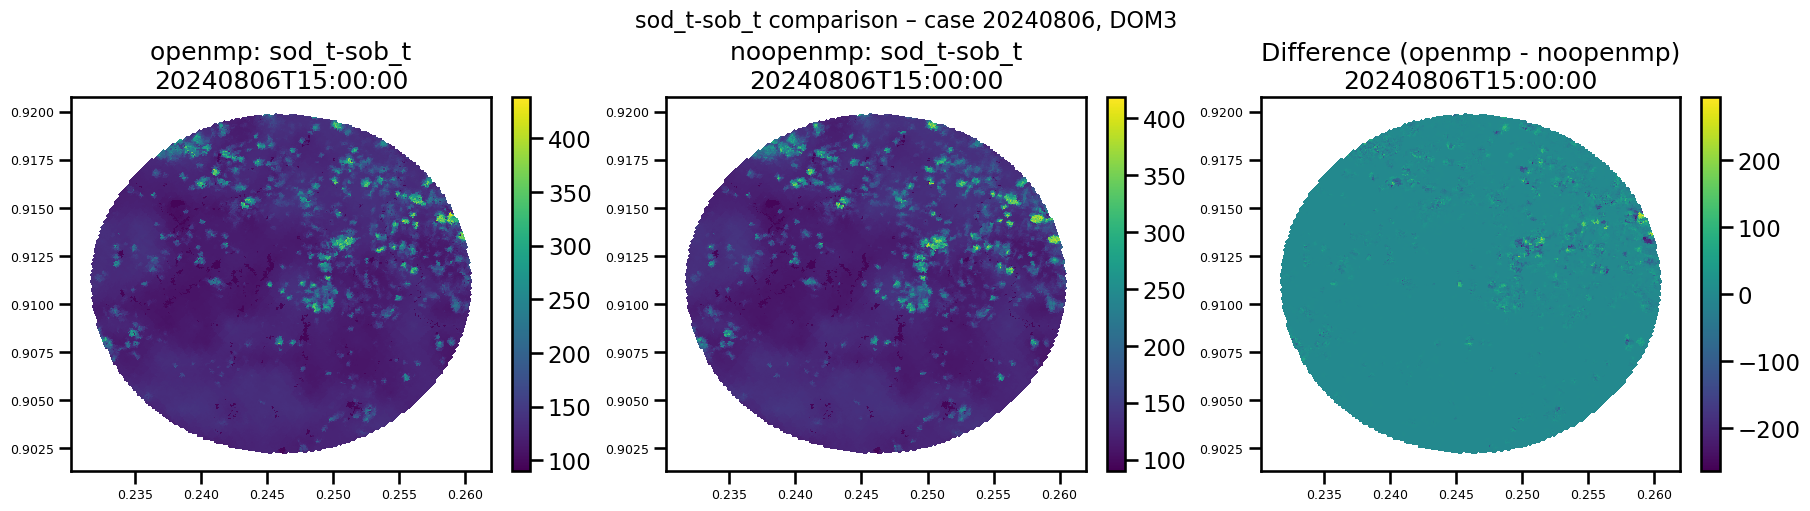

In [10]:
plot_case_comparison_map(
    data2d=data2d,
    grids=grids,
    case_date="20240806", #case1: 20240806 , case 2: 20240928 ,case3: 20241110 
    dom="3",
    var="sod_t-sob_t",
    time_str="15:00:00",
    run1="openmp",
    run2="noopenmp"
)


## Variabel-Mean Timeseries

In [7]:
def plot_2dvariable_timeseries_comparison(
    case_date: str,
    run1: str,
    run2: str,
    dom: str,
    variable: str,
    title: str = "",
    mean_dims=('ncells',)
):
    """
    Plots the time evolution of a variable (or expression) averaged over spatial dimensions,
    comparing two runs of a given case and domain.

    Parameters:
        case (str): The date string of the case, e.g. "20240806"
        run1 (str): First run name, e.g. "openmp"
        run2 (str): Second run name, e.g. "noopenmp"
        dom (str): Domain key, e.g. "3"
        variable (str): Variable name or expression, e.g. "sod_t - sob_t"
        title (str): Plot title
        mean_dims (tuple): Dimensions to average over, default is ('ncells',)
    """
    
    # Zugriff auf Daten
    d1 = data2d[case_date][run1][f"d{dom}"]
    d2 = data2d[case_date][run2][f"d{dom}"]
    
    
    def eval_var(ds, expression):
        # Map alle Variablennamen im Ausdruck auf DataArrays
        local_vars = {v: ds[v] for v in ds.data_vars}
        return eval(expression, {}, local_vars)
        
    # Mittelwert berechnen
    var1 = eval_var(d1, variable).mean(dim=mean_dims)
    var2 = eval_var(d2, variable).mean(dim=mean_dims)

    # Plotten
    plt.figure(figsize=(10, 6))
    var1.plot(label=run1)
    var2.plot(label=run2)

    plt.title(title or f"{variable} over time (domain {dom})")
    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


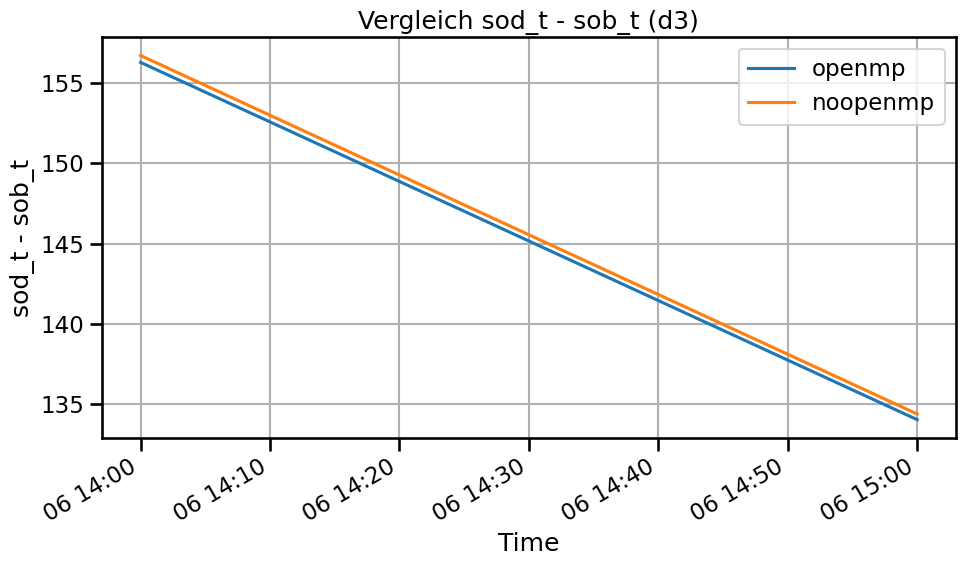

In [8]:
plot_2dvariable_timeseries_comparison(
    case_date="20240806", #case1: 20240806 , case 2: 20240928 ,case3: 20241110 
    run1="openmp",
    run2="noopenmp",
    dom="3",
    variable="sod_t - sob_t",
    title="Vergleich sod_t - sob_t (d3)"

)


In [9]:
data3d['20240928']['noopenmp']['d1']


<xarray.Dataset>
Dimensions:  (time: 7, alt: 61, ncells: 142720)
Coordinates:
  * time     (time) datetime64[ns] 2024-09-28T12:00:00 ... 2024-09-28T18:00:00
  * alt      (alt) float64 1.5e+04 1.475e+04 1.45e+04 ... 500.0 250.0 0.0
Dimensions without coordinates: ncells
Data variables:
    clc      (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
    qv       (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
    temp     (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
    pres     (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
    qc       (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
    qi       (time, alt, ncells) float32 dask.array<chunksize=(1, 61, 142720), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  99
    uuidOfHGrid:          7fad9f84-2562-8608-875c-071c55c029c0
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2024.10; revision: icon-2024.10-public-0-g...
    history:              /home/b/b383413/workspace/icon-build/bin/icon at 20...
    references:           see MPIM/DWD publications
    comment:              Daniel Kloster (b383413) on l10555 (Linux 4.18.0-51...